# <center> Лабораторная 2

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

### Task 1. 

Для заданного ниже объекта s проделайте следующее:
1. Создайте новый Series, значения которого совпадают со значениями s, а индексы - целочисленные значения от 5 до 20, не включая 20. 
2. Выберите из нового s только целочисленные элементы и вычислите их дисперсию. (\*)

Все полученные результаты округлите до 2-х знаков после запятой.


##### Пояснения:
(\*) Целочисленные значения - значения, имеющие тип int.
- Дисперсия рассчитывается с помощью функции из библиотеки numpy: np.var( , ddof=0) или встроенной в python функции: .var(ddof=1)

In [138]:
s = pd.Series(data=['13', 2, 77.1, 'red', 8, -341, 12.42, "34", 19.02, 72, 1, 87, 12.03, "green", 0.05], 
              index=range(6, 36, 2))
### Type your code here
s1 = pd.Series(data = s.values, index=range(5, 20))
s2 = s1[s1.apply(type) == int]
np.var(s2, ddof=0), s2

(np.float64(20704.916666666668),
 6        2
 9        8
 10    -341
 14      72
 15       1
 16      87
 dtype: object)

### Task 2. 
1. Сгенерируйте Series из 100 значений нормально распределённой СВ (np.random.normal с дефолтными параметрами - нулевым средним и единичной дисперсией).
2. Возведите каждое значение серии в 3 степень, а значения индекса увеличьте в 3 раза. 
3. Ответьте на следующие вопросы через запятую (без пробелов) (\*)
    - 1) Выведите сумму элементов, строго меньших 2.6, имеющих чётные значения индекса. 
    - 2) Выведите количество значений серии больше нуля.

#### Пояснения:
 - Определенное значение seed нужно, чтобы ответы у всех выполняющих
это задание были одинаковые и их можно было проверить (так как генерируются
одинаковые series).
 - Следует внимательнее использовать [ ] для выбора данных по нескольким условиям:
либо выбирать данные последовательно, либо сразу по нескольким условиям,
но через оператор &. Отличие оператора and от оператора &: and - выводит
последнее проверенное значение, & - выводит пересечение значений.
Пример: s[ _  &  _ ].sum() 

In [139]:
np.random.seed(242)
s_star = pd.Series(np.random.normal(size=100))
s = pd.Series(data=s_star**3, index=s_star.index*3)

s[(s<2.6)&(s.index%2==0)].sum(), s[s>0].count()

(np.float64(-0.06685511127895016), np.int64(17))

#### Структура популярного датасета **«Титаник»** выглядит следующим образом:

| Колонка         | Тип данных | Описание                                     |
|-----------------|------------|----------------------------------------------|
| PassengerId     | integer    | Уникальный номер пассажира                   |
| Survived        | integer    | Показатель выживания (0 — погиб, 1 — выжил) |
| Pclass          | integer    | Класс билета (1-й, 2-й, 3-й классы)         |
| Name            | object     | Имя пассажира                                |
| Sex             | object     | Пол пассажира («male» или «female»)         |
| Age             | float      | Возраст пассажира                            |
| SibSp           | integer    | Количество братьев/сестер/супругов на борту |
| Parch           | integer    | Количество родителей/детей на борту         |
| Ticket          | object     | Номер билета                                 |
| Fare            | float      | Стоимость проезда                           |
| Cabin           | object     | Номер каюты (частично отсутствуют данные)   |
| Embarked        | object     | Порт посадки («C», «Q», «S»)                 |



### Task 3.
Используя датасет Titanic, провести Exploratory Data Analysis (EDA) (с помощью описательной статистики), выявить основные факторы, повлиявшие на выживаемость пассажиров, рассчитать долю спасённых мужчин и женщин.

In [140]:
df = pd.read_csv("titanic.csv")

print(df.describe(include="all"))


        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1   577   
mean     446.000000    0.383838    2.308642                      NaN   NaN   
std      257.353842    0.486592    0.836071                      NaN   NaN   
min        1.000000    0.000000    1.000000                      NaN   NaN   
25%      223.500000    0.000000    2.000000                      NaN   NaN   
50%      446.000000    0.000000    3.000000                      NaN   NaN   
75%      668.500000    1.000000    3.000000                      NaN   NaN   
max      891.000000    1.000000    3.000000                      NaN   NaN   

               Age       SibSp       Parch  Ticket        Fare 

In [141]:
print('Количество дубликатов:', df.duplicated().sum())

display(df.isna().sum().to_frame("Пропущенные значения"))

Количество дубликатов: 0


,Пропущенные значения
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [142]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 20, 35, 60, 80],
    labels=['Kid', 'Teen', 'Young', 'Adult', 'Senior']
)

df['FareGroup'] = pd.qcut(df['Fare'], 4, duplicates='drop')


for col in ['Pclass', 'Sex', 'FamilySize', 'AgeGroup','FareGroup','Embarked']:
    display(df.groupby(col, observed=False)["Survived"].agg(["count", "sum", "mean"]))

,count,sum,mean
Pclass,,,
1,216,136,0.629630
2,184,87,0.472826
3,491,119,0.242363


,count,sum,mean
Sex,,,
female,314,233,0.742038
male,577,109,0.188908


,count,sum,mean
FamilySize,,,
1,537,163,0.303538
2,161,89,0.552795
3,102,59,0.578431
4,29,21,0.724138
5,15,3,0.200000
6,22,3,0.136364
7,12,4,0.333333
8,6,0,0.000000
11,7,0,0.000000


,count,sum,mean
AgeGroup,,,
Kid,69,40,0.579710
Teen,110,42,0.381818
Young,318,125,0.393082
Adult,195,78,0.400000
Senior,22,5,0.227273


,count,sum,mean
FareGroup,,,
"(-0.001, 7.91]",223,44,0.197309
"(7.91, 14.454]",224,68,0.303571
"(14.454, 31.0]",222,101,0.454955
"(31.0, 512.329]",222,129,0.581081


,count,sum,mean
Embarked,,,
C,168,93,0.553571
Q,77,30,0.389610
S,644,217,0.336957



#### Вот таблица, отображающая структуру датасета bank_data.csv:

| Column Name    | Type                 | Description                             |
|----------------|----------------------|-----------------------------------------|
| Client_ID      | int                  | Идентификатор клиента                   |
| Date           | string               | Дата рождения клиента (формат: YYYY-MM-DD) |
| Profession     | category/string      | Профессиональная деятельность клиента   |
| Income         | float                | Годовой доход клиента                    |
| Loan_Balance   | float                | Текущий остаток по кредиту               |
| Gender         | category/string      | Пол клиента ("Male"/"Female")           |


### Task 4.
Загрузите данные из файла 'bank_data.csv'. Проверьте структуру загруженных данных: выведите первые 5 записей и размеры таблицы (строки x столбцы).Посчитайте общее число клиентов банка и количество уникальных профессий среди клиентов.
Проверить наличие пропусков в данных и заполнить пустые значения средней величиной соответствующего столбца.


In [143]:
df = pd.read_csv("bank_data.csv")

display(df.head())
print("Размер таблицы", df.shape)

print("Количество клиентов: ", df["Client_ID"].nunique())
print("Количество уникальных профессий:", df["Profession"].nunique())

display(df.isnull().sum().to_frame("Количество пропусков в данных"))
df = df.fillna(df.mean(numeric_only=True))

,Client_ID,Date,Profession,Income,Loan_Balance,Gender
0,1,1960-01-01,Doctor,51640.921919,11493.764542,Male
1,2,1960-01-15,Engineer,NaN,6241.044750,Female
2,3,1960-01-30,Designer,NaN,7868.212019,Male
3,4,1960-02-14,Engineer,53358.260364,15742.228546,Female
4,5,1960-02-29,Engineer,38142.883168,10566.352053,Female


Размер таблицы (1000, 6)
Количество клиентов:  1000
Количество уникальных профессий: 5


,Количество пропусков в данных
Client_ID,0
Date,0
Profession,0
Income,50
Loan_Balance,0
Gender,0


### Task 5.
Преобразуйте строку 'Date' в тип datetime и извлеките из нее год, месяц и день рождения клиентов отдельно в новые столбцы.
Отфильтруйте записи клиентов старше 30 лет и подсчитайте средний доход для этой выборки.
Проведите группировку клиентов по профессиям и вычислите среднюю сумму кредита для каждой профессии.
Для всех кредитных сумм выполните стандартизацию (приведение к нормальному распределению).
Удалите ненужные столбцы и преобразуйте категорию профессии в числовой вид (one-hot encoding).
Сохраните обработанные данные в новый CSV-файл для дальнейшего использования в обучении нейронных сетей.

In [144]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['birth_year'] = df['Date'].dt.year
df['birth_month'] = df['Date'].dt.month
df['birth_day'] = df['Date'].dt.day

current_year = pd.Timestamp.now().year
df['age'] = current_year - df['birth_year']

clients_over_30 = df[df['age'] > 30]
print("Средний доход клиентов старше 30 лет:", clients_over_30['Income'].mean())

display(df.groupby('Profession')['Loan_Balance'].mean().to_frame("Средняя сумма остатка кредита"))

df['Loan_Balance_norm'] = (df['Loan_Balance'] - df['Loan_Balance'].mean()) / df['Loan_Balance'].std()

display(df['Loan_Balance_norm'].head().to_frame("Стандартизированная кредитная сумма"))

df = df.drop(columns=['Date', 'Loan_Balance'])
df = pd.get_dummies(df, columns=['Profession'], prefix='Profession')

df.to_csv('bank_data_processed.csv', index=False)

Средний доход клиентов старше 30 лет: 51286.45659561021


,Средняя сумма остатка кредита
Profession,
Designer,9918.913324
Developer,9994.977918
Doctor,10512.587489
Engineer,10112.137794
Manager,9916.911214


,Стандартизированная кредитная сумма
0,0.287075
1,-0.790704
2,-0.456834
3,1.158797
4,0.096784


#### Информация для последующих заданий
- Для всех последующих заданий будем использовать обезличенные транзакционные банковские данные. Для этого считайте в переменные tr_mcc_codes, tr_types, transactions и gender_train из одноимённых таблиц из папки data. Для таблицы transactions используйте только первые n=1000000 строк. Обратите внимание на разделители внутри каждого из файлов - они могут различаться!

#### Описание данных
#### Таблица ```transactions.csv```
##### Описание
Таблица содержит историю транзакций клиентов банка за один год и три месяца.

##### Формат данных

```
customer_id,tr_datetime,mcc_code,tr_type,amount,term_id
111111,15 01:40:52,1111,1000,-5224,111111
111112,15 15:18:32,3333,2000,-100,11122233
...
```
##### Описание полей

 - ```customer_id``` — идентификатор клиента;
 - ```tr_datetime``` — день и время совершения транзакции (дни нумеруются с начала данных);
 - ```mcc_code``` — mcc-код транзакции;
 - ```tr_type``` — тип транзакции;
 - ```amount``` — сумма транзакции в условных единицах со знаком; ```+``` — начисление средств клиенту (приходная транзакция), ```-``` — списание средств (расходная транзакция);
 - ```term_id``` — идентификатор терминала;


#### Таблица ```gender_train.csv```

##### Описание
Данная таблица содержит информацию по полу для части клиентов, для которых он известен. Для остальных клиентов пол неизвестен.

##### Формат данных
```
customer_id,gender
111111,0
111112,1
...
```

##### Описание полей
 - ```customer_id``` — идентификатор клиента;
 - ```gender``` — пол клиента;

#### Таблица ```tr_mcc_codes.csv```

##### Описание
Данная таблица содержит описание mcc-кодов транзакций.

##### Формат данных
```
mcc_code;mcc_description
1000;словесное описание mcc-кода 1000
2000;словесное описание mcc-кода 2000
...
```

##### Описание полей
 - ```mcc_code``` – mcc-код транзакции;
 - ```mcc_description``` — описание mcc-кода транзакции.

#### Таблица ```tr_types.csv```

##### Описание
Данная таблица содержит описание типов транзакций.

##### Формат данных
```
tr_type;tr_description
1000;словесное описание типа транзакции 1000
2000;словесное описание типа транзакции 2000
...
```

##### Описание полей
 - ```tr_type``` – тип транзакции;
 - ```tr_description``` — описание типа транзакции;

### Task 6.
1. В датафрейме transactions задайте столбец  customer_id в качестве индекса.
2. Выделите клиента с максимальной суммой транзакции (то есть с максимальным приходом на карту). (\*)
3. Найдите у него наиболее часто встречающийся модуль суммы приходов/расходов. (\**)


##### Выберите все верные пункты:
    - 1) 1122957.89
    - 2) 15721.41
    - 3) 22459.16
    - 4) 13475494.63
    - 5) 107407.78
    - 6) 65019.26

##### Пояснения:
(\*) Если у клиента были транзакции [-10000, 10, 0, -10], то максимумом будет являться значение 10. <br>
(\**) Если у клиента были транзакции [-10000, 10, 0, -10], то наиболее встречающийся модуль суммы транзакций равен 10, и встретился он 2 раза.

In [155]:
### Type your code here
transactions= pd.read_csv("transactions.csv", nrows=1e6).set_index('customer_id')

max_transaction = transactions['amount'].max()
client_max = transactions[transactions['amount'] == max_transaction].index[0]
client_transactions = transactions.loc[client_max]

most_amount = client_transactions['amount'].abs().mode().iloc[0]
print(f"client_id: {client_max}; наиболее встречающийся модуль суммы приходов/расходов {most_amount}")

client_id: 26782922; наиболее встречающийся модуль суммы приходов/расходов 22459.16


### Task 7.
Считайте в переменные tr_mcc_codes, tr_types, transactions и customers_gender_train. В transactions считайте только первые 1000000 строк. Соедините transactions со всеми остальными таблицами (tr_mcc_codes, tr_types, gender_train). Причём с customers_gender_train необходимо смёрджиться с помощью left join, а с оставшимися датафреймами - через inner. После получения результата таблицы gender_train, tr_types, tr_mcc_codes можно удалить. В результате соединения датафреймов должно получиться 999584 строки. Выделите из поля tr_datetime относительный день tr_day (первое число до точного времени). 

1. Разбейте расходы (отрицательные значения сумм) на 5 бакетов amount_bucket равного объёма (с помощью pd.qcut), разбив все траты на категории 'Very High', 'High', 'Middle', 'Low', 'Very Low'. (\*)
2. Оставшиеся неотрицательные траты отнесите к категории 'Income'.
(воспользуйтесь функцией .cat.add_categories('Income') для того, чтобы добавить новую категорию 'Income' к категориям 'Very High', 'High', 'Middle', 'Low', 'Very Low', а затем заполните пустые значения новой категорией).
3. Из поля tr_datetime выделите час tr_hour, в который произошла транзакция, как первые 2 цифры до ":". (\**)
3. После этого постройте сводную таблицу, значениями в которой является пол gender, индексы - tr_hour, столбцы - amount_bucket.
4. Отрисуйте полученные результаты в виде тепловой карты, передав их в созданную функцию plot_pivot_table.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) Ночные поступления денег (01-05 часов) в более чем 85% случаев являются мужскими.
     2) Посмотрев на долю мужчин в поступлениях средств (Income), можно сделать вывод, что количество поступлений средств женщинам в целом больше, чем мужчинам.
     3) Самые низкие траты в 3 часа ночи осуществляются в более 70% случаев женщинами.
     4) Существуют особые часы в мелких тратах, когда женщины тратят намного больше мужчин (>80%)
     5) Посмотрев на долю мужчин в максимальных тратах средств (Very High), можно сделать вывод, что количество высоких трат в каждый возможный час мужчин больше, чем у женщин.

##### Пояснения:
(\*) Обратите внимание, что в категории Very High Должны оказаться максимальные по модулю отрицательные транзакции. <br>
(\**) Например, для строки "0 10:23:26" час будет равен 10, а для строки "6 07:08:31"- 07. Можно воспользоваться функциями str.split() или str.find() и 
функцией .apply(lambda x: x[])

In [ ]:
transactions = pd.read_csv('transactions.csv', nrows=1e6)
customers_gender_train = pd.read_csv('gender_train.csv')

tr_mcc_codes = pd.read_csv('tr_mcc_codes.csv', sep=';')
tr_types = pd.read_csv('tr_types.csv', sep=';')

transactions = transactions.merge(tr_mcc_codes, on='mcc_code', how='inner')
transactions = transactions.merge(tr_types, on='tr_type', how='inner')
transactions = transactions.merge(customers_gender_train, on='customer_id', how='left')
print(transactions.shape)

(999584, 9)


C:\Temp\ipykernel_9396\2287759739.py:29: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = pd.pivot_table(


Ответы на утверждения:
1) True;
2) False;
3) True; 
4) False;
5) True;



amount_bucket,High,Low,Middle,Very High,Very Low,income
tr_hour,,,,,,
0,0.585,0.546,0.529,0.574,0.518,0.737
1,0.586,0.535,0.600,0.592,0.450,0.966
2,0.437,0.388,0.512,0.539,0.349,0.966
3,0.386,0.393,0.404,0.548,0.284,0.945
4,0.427,0.464,0.405,0.525,0.289,0.914
5,0.459,0.380,0.444,0.525,0.374,0.881
6,0.460,0.431,0.417,0.526,0.366,0.815
7,0.464,0.448,0.476,0.523,0.413,0.758
8,0.477,0.455,0.457,0.563,0.432,0.725


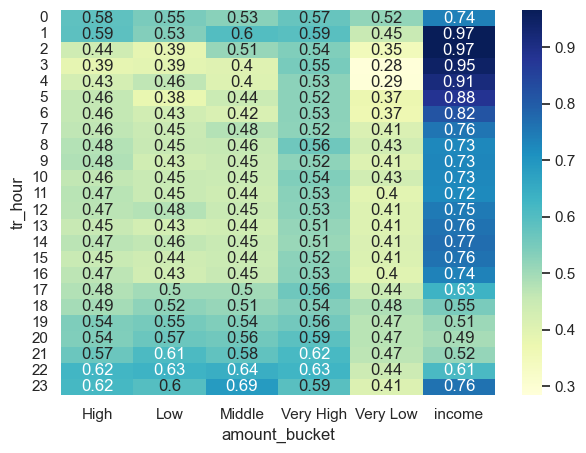

In [ ]:
transactions['tr_day'] = transactions['tr_datetime'].str.split().str[0].astype(int)

# 1. Разбиваем
costs = transactions[transactions['amount'] < 0].copy()
costs['amount_bucket'] = pd.qcut(
    costs['amount'].abs(),
    q=5,
    labels=['Very Low', 'Low', 'Middle', 'High', 'Very High']
)

transactions['amount_bucket'] = None
transactions.loc[costs.index, 'amount_bucket'] = costs['amount_bucket']

# 2. income
transactions['amount_bucket'] = transactions['amount_bucket'].astype('category')
transactions['amount_bucket'] = transactions['amount_bucket'].cat.add_categories(['income'])
transactions['amount_bucket'] = transactions['amount_bucket'].fillna('income')

# 3. Выделяем час
transactions['tr_hour'] = (
    transactions['tr_datetime']
    .str.split()
    .str[1]
    .str[:2]
    .astype(int)
)

# 4. Сводная таблица
table = pd.pivot_table(
    transactions,
    values='gender',
    index='tr_hour',
    columns='amount_bucket',
    aggfunc='mean'
)

plt.figure(figsize=(7, 5))
sns.heatmap(table, annot=True,  cmap="YlGnBu")
print(
f"""Ответы на утверждения:
1) {(table.loc[1:5, 'income'] > 0.85).mean() > 0.5};
2) {table['income'].mean() < 0.5};
3) {table.loc[3, 'Very Low'] < 0.3}; 
4) {(table['Very Low'] < 0.2).any()};
5) {(table['Very High'] > 0.5).all()};
"""
)

### Task 8.
1. Измените тип поля tr_day на int.
2. Выберите из transactions все MCC коды, которые встретились в выборке более чем 60000 раз.
3. Сгруппируйте отфильтрованный датафрейм по дню и MCC-коду, получая средние значения суммы amount.  
4. Далее отрисуйте зависимость средних сумм (может пригодится метод unstack()) по каждому из MCC-кодов по дням.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) 2 из полученных MCC-кодов связаны с финансовыми институтами
     2) 2 MCC кода, связанные со снятием наличности имеют в целом разные знаки (в одном случае почти везде - траты, в другом - пополнения)
     3) Бакалейные магазины обладают максимальными средними тратами среди выбранных MCC-кодов
     4) Денежные переводы имеют как минимум 3 явных минимума средних
     5) Категория "Звонки с использованием телефонов, считывающих магнитную ленту" имеет визуально очень большую дисперсию. 

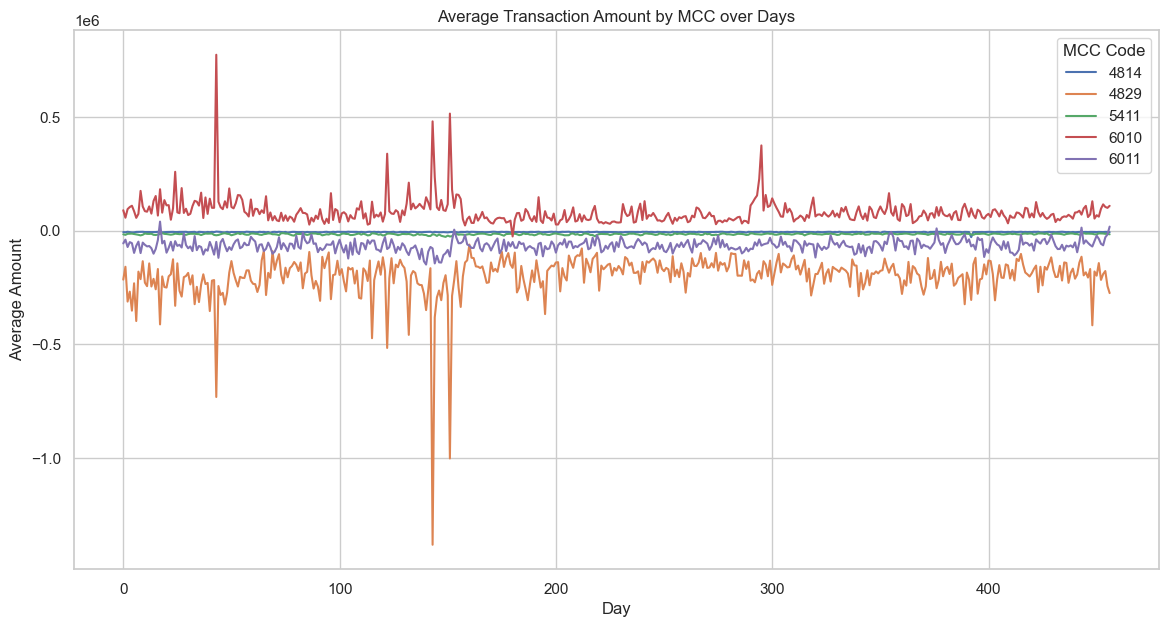

In [ ]:
transactions['tr_day'] = transactions['tr_day'].astype(int)

mcc_counts = transactions['mcc_code'].value_counts()

filtered = transactions[transactions['mcc_code'].isin(mcc_counts[mcc_counts > 60000].index)]

grouped = (
    filtered
    .groupby(['tr_day', 'mcc_code'])['amount']
    .mean()
)

pivot = grouped.unstack()

pivot.plot(figsize=(14, 7))

plt.title("Average Transaction Amount by MCC over Days")
plt.xlabel("Day")
plt.ylabel("Average Amount")

plt.legend(title="MCC Code")
plt.show()

### Task 9:
Считайте данные из файла 'winemag-data-130k-v2.csv'. 
а) Постройте точечный график (Scatter plot), по оси х отложите points, а по y - price.
б) Постройте график Barplot количества вин по странам.

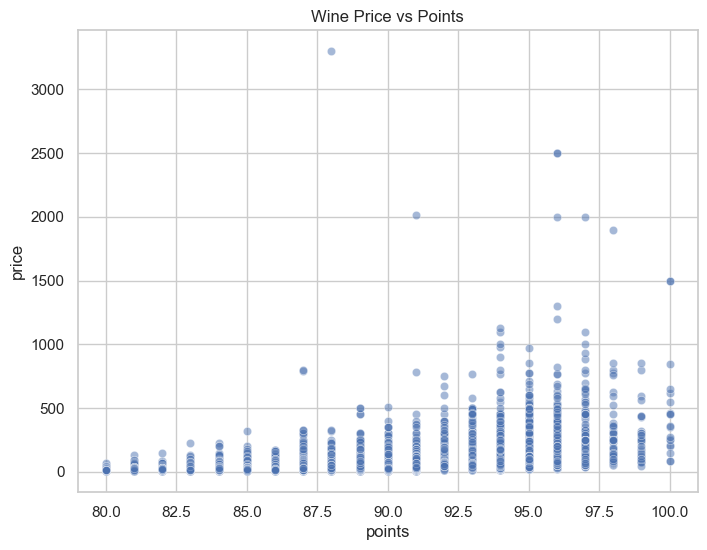

In [172]:
df = pd.read_csv('winemag-data-130k-v2.csv')
# убираем NaN
scatter_df = df[['points', 'price']].dropna()

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=scatter_df,
    x='points',
    y='price',
    alpha=0.5
)

plt.title('Wine Price vs Points')
plt.show()

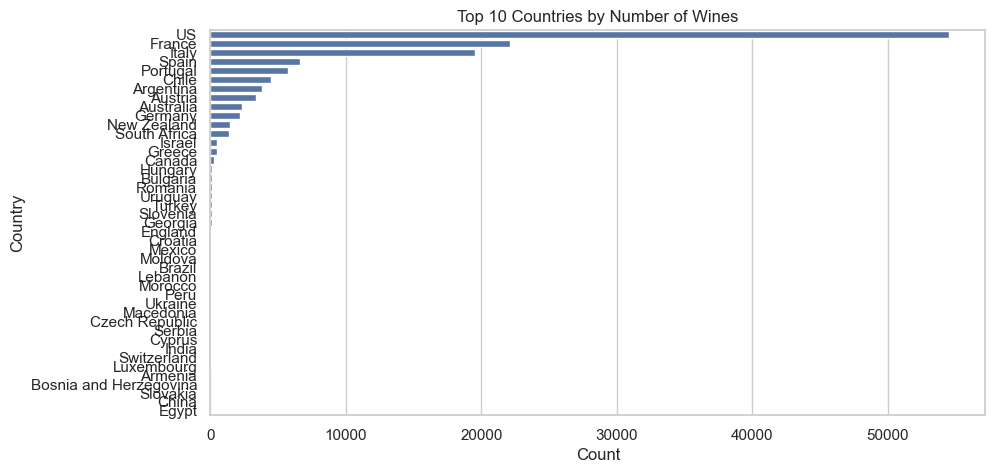

In [ ]:
df = pd.read_csv('winemag-data-130k-v2.csv')

country_counts = df['country'].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.xlabel('Count')
plt.ylabel('Country')

plt.show()